# Практическая работа №2 "Создание конкуртной нейронной сети"

**Цель работы:** изучить топологию и алгоритм функционирования конкурентной нейронной сети.

Реализуется конкурентная нейронная сеть для распознавания 5 образов размером $6 \times 6$: **→, ↔, ←, ↓, ↲**.

Алгоритм выполнения:
1. Задаются идеальные бинарные образы.
2. Для каждого образа создаются зашумлённые версии с искажением 10%, 20%, 30% и 40%.
3. Все изображения преобразуются в векторы длины 36.
4. Выполняется обучение конкурентной нейронной сети.
5. Для каждого входного образа определяется нейрон-победитель.
6. Результаты представляются в виде матрицы кластеров.

В качестве критерия выбора нейрона-победителя используется выражение:

$KRIT_j = f_j \cdot \|X - W_j\|$

где:
- $X$ — входной вектор,
- $W_j$ — вектор весов $j$-го нейрона,
- $f_j$ — число побед $j$-го нейрона.

Победителем считается нейрон, для которого значение критерия минимально.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

# ============================================
# 1. Исходные образы 6x6
# ============================================

L = np.array([
    [1, 1, 1, 0, 1, 1],
    [1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 1],
    [1, 1, 1, 0, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

U = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

T = np.array([
    [1, 1, 0, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

O = np.array([
    [1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [0, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 1],
    [1, 1, 0, 1, 1, 1]
], dtype=float)

K = np.array([
    [1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1]
], dtype=float)

base_images = {
    "→": L,
    "↔": U,
    "←": T,
    "↓": O,
    "↲": K
}

In [2]:
# ============================================
# 2. Вспомогательные функции
# ============================================

def to_vector(img):
    return img.T.reshape(-1).astype(float)

def normalize_vector(x):
    norm = np.linalg.norm(x)
    return x / norm if norm != 0 else x

def add_noise(img, flips):
    noisy = img.copy().reshape(-1)
    idx = np.random.choice(len(noisy), size=flips, replace=False)
    noisy[idx] = 1 - noisy[idx]
    return noisy.reshape(img.shape)

def show_images(images_dict, title):
    fig, axes = plt.subplots(1, len(images_dict), figsize=(14, 3))
    fig.suptitle(title, fontsize=14)
    for ax, (name, img) in zip(axes, images_dict.items()):
        ax.imshow(img, cmap="gray_r")
        ax.set_title(name)
        ax.axis("off")
    plt.show()

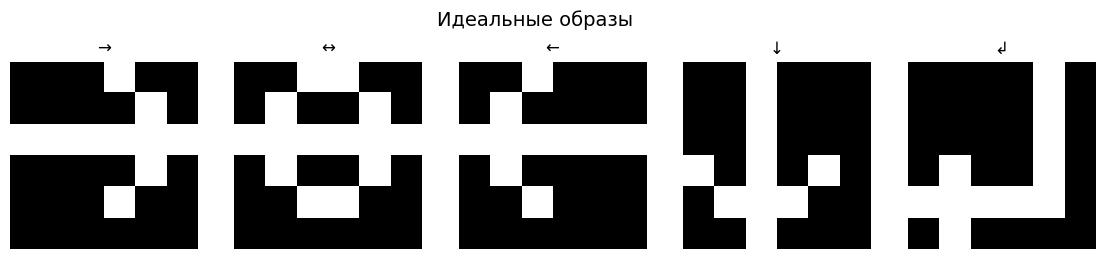

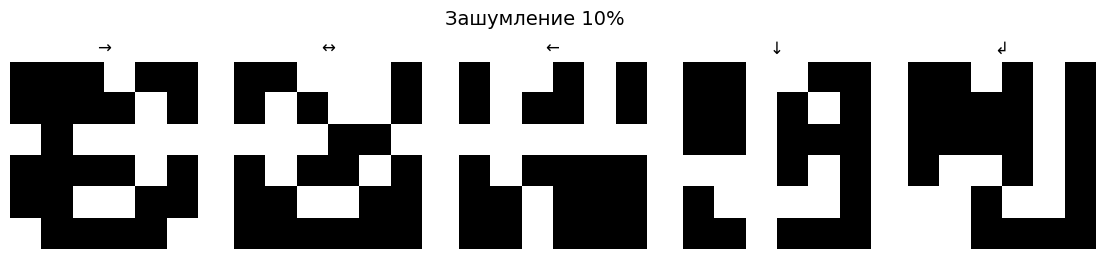

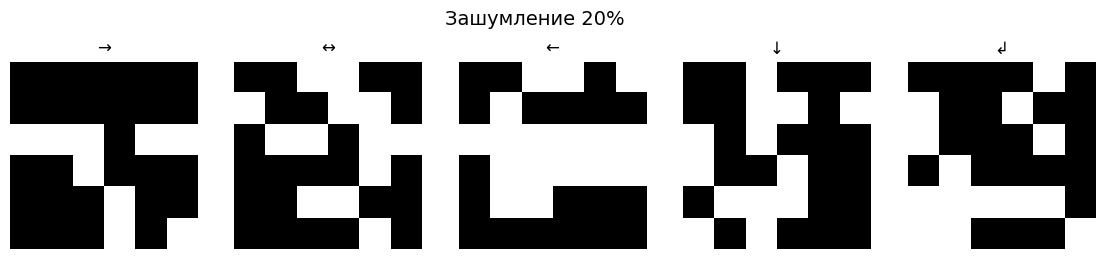

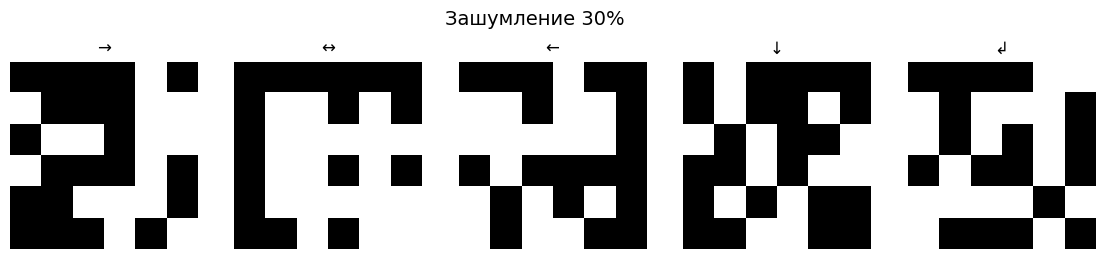

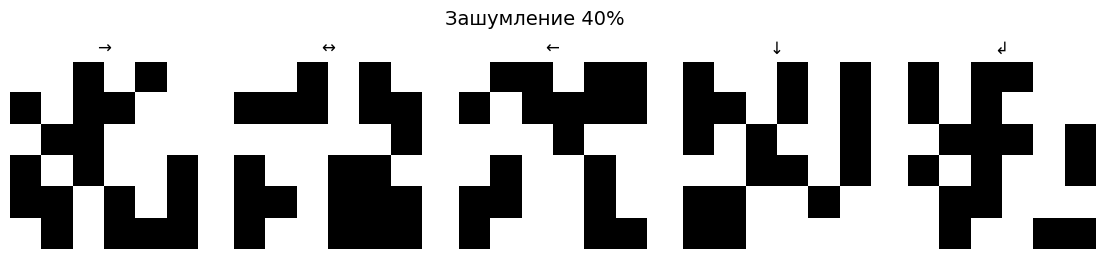

In [3]:
# ============================================
# 3. Создание зашумленных образов
# ============================================

noise_levels = {
    "0%": 0,
    "10%": 4,
    "20%": 7,
    "30%": 11,
    "40%": 14
}

all_images = {}
for noise_name, flips in noise_levels.items():
    all_images[noise_name] = {}
    for label, img in base_images.items():
        if flips == 0:
            all_images[noise_name][label] = img.copy()
        else:
            all_images[noise_name][label] = add_noise(img, flips)

show_images(base_images, "Идеальные образы")
show_images(all_images["10%"], "Зашумление 10%")
show_images(all_images["20%"], "Зашумление 20%")
show_images(all_images["30%"], "Зашумление 30%")
show_images(all_images["40%"], "Зашумление 40%")

In [5]:
# ============================================
# 4. Подготовка обучающей выборки
# ============================================

train_labels = list(base_images.keys())
X_train = np.array([normalize_vector(to_vector(base_images[label])) for label in train_labels])

# ============================================
# 5. Обучение конкурентной сети
# ============================================

def train_competitive_network(X, m=5, h=0.05, epochs=30, seed=42):
    np.random.seed(seed)
    n = X.shape[1]

    W = np.random.rand(n, m) * 2 - 1
    for j in range(m):
        W[:, j] = normalize_vector(W[:, j])

    f = np.ones(m)

    for _ in range(epochs):
        for x in X:
            krit = [0.0 for _ in range(m)]

            # вычисление KRIT_j
            for j in range(m):
                s = 0.0
                for i in range(n):
                    s += (x[i] - W[i][j]) ** 2
                krit[j] = math.sqrt(s) * f[j]

            # поиск нейрона-победителя
            winner = 0
            min_value = krit[0]
            for j in range(1, m):
                if krit[j] < min_value:
                    min_value = krit[j]
                    winner = j

            # увеличение счетчика побед
            f[winner] += 1

            # коррекция весов нейрона-победителя
            for i in range(n):
                W[i][winner] = W[i][winner] + h * (x[i] - W[i][winner])

    return W, f

In [6]:
# ============================================
# 6. Классификация образов
# ============================================

def predict_cluster(x, W, f):
    x = normalize_vector(x)
    krit = np.array([np.linalg.norm(x - W[:, j]) * f[j] for j in range(W.shape[1])])
    return np.argmin(krit) + 1  # нумерация с 1

def evaluate_network(all_images, W, f):
    labels = ["→", "↔", "←", "↓", "↲"]
    levels = ["0%", "10%", "20%", "30%", "40%"]
    result = np.zeros((5, 5), dtype=int)

    for i, label in enumerate(labels):
        for j, level in enumerate(levels):
            x = to_vector(all_images[level][label])
            result[i, j] = predict_cluster(x, W, f)

    return result

In [7]:
# ============================================
# 7. Эксперимент 1: m = 5
# ============================================

W5, f5 = train_competitive_network(X_train, m=5, h=0.05, epochs=30, seed=42)
REZ5 = evaluate_network(all_images, W5, f5)

print("Результат для m = 5")
print("Строки: →, ↔, ←, ↓, ↲")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ5)

Результат для m = 5
Строки: →, ↔, ←, ↓, ↲
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 5 5 5]
 [5 5 5 5 3]
 [3 3 3 5 5]
 [2 2 2 5 2]
 [4 4 4 4 4]]


In [8]:
# ============================================
# 8. Эксперимент 2: m = 3
# ============================================

W3, f3 = train_competitive_network(X_train, m=3, h=0.05, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 3")
print("Строки: →, ↔, ←, ↓, ↲")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Результат для m = 3
Строки: →, ↔, ←, ↓, ↲
Столбцы: 0%, 10%, 20%, 30%, 40%
[[3 2 2 2 2]
 [1 1 2 2 2]
 [1 1 2 2 2]
 [2 2 2 2 2]
 [3 2 2 2 2]]


**Выводы:**
Конкурентная сеть пригодна для кластеризации чистых данных с известным числом классов, но неэффективна для распознавания сильно зашумлённых образов (≥30% шума).

## Контрольные вопросы

1. В чём заключается смысл самообучения нейронной сети?

**Ответ:**
Конкурентная нейронная сеть относится к самоорганизующимся нейронным сетям и обучается без учителя. Такие сети способны адаптироваться к входным данным, используя внутренние зависимости в обучающей выборке.

2. Как выполняется обучение конкурентной нейронной сети?

**Ответ:**
При обучении сети определяется нейрон-победитель, для которого значение  yj  максимально. После этого веса нейрона-победителя корректируются по правилу:

wij(t+1)=wij(t)+β(xi−wij(t))

где  β  — скорость обучения.

Смысл данного правила состоит в том, что вектор весов нейрона-победителя приближается к входному вектору. Это позволяет нейрону лучше распознавать похожие образы при последующих подачах входных данных.

3. Каким образом определяется нейрон-победитель в конкурентной нейронной сети?

**Ответ:**
В конкурентных нейронных сетях определение нейрона-победителя происходит на основе принципа «победитель получает всё» . При подаче входного вектора в такой сети активизируется только один нейрон, а выходные значения остальных нейронов устанавливаются равными нулю.

4. Где используются самоорганизующиеся нейронные сети?

**Ответ:**
- **Медицина.**
Кластеризация медицинских данных, анализ медицинских изображений, обработка биологических сигналов, персонализированная медицина.
- **Промышленность и производство.**
Кластеризация производственных процессов, контроль качества продукции,прогнозирование поломок оборудования, оптимизация производственных процессов.

- **Управление и робототехника.**
Адаптивное управление роботами, мониторинг состояния оборудования, обработка данных датчиков в режиме реального времени.

5. Каковы основные достоинства и недостатки конкурентной нейронной сети?

**Ответ:**

**Достоинства**

Обучение без учителя,
разбиение входного пространства на области решений,
избирательность паттернов,
способность обрабатывать неструктурированные данные,
адаптация к входным данным.

**Недостатки**

Ограниченная объяснимость («чёрный ящик»),
чувствительность к начальной инициализации весов,
проблема переобучения,
высокая вычислительная сложность,
ограничения при работе с малыми объёмами данных,
сложность масштабирования.
